<a href="https://colab.research.google.com/github/winston-k/Wi20260413/blob/main/py2208h_lrg1p.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Linear Regression Example, HDB Prices Estimation ...

In [14]:
# This time, we use 2 independent/input variables

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as seabornInstance
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics
%matplotlib inline
from google.colab import drive

drive.mount('/content/drive')

# Load the dataset
file_path = "/content/drive/My Drive/Emeritus/Wi20260417/Module2-7/resale-sample.csv"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [16]:
dataset = pd.read_csv(file_path)

In [17]:
import os
# List files in the specified directory to verify the path
path_to_check = '/content/drive/My Drive/Emeritus/Wi20260417/Module2-7/'
if os.path.exists(path_to_check):
    print(f"Contents of {path_to_check}:")
    for item in os.listdir(path_to_check):
        print(item)
else:
    print(f"Directory not found: {path_to_check}")

Contents of /content/drive/My Drive/Emeritus/Wi20260417/Module2-7/:
celebs2.csv
lrg1p.ipynb
resale-sample.csv
lrg1.ipynb


In [18]:
dataset.shape

(2000, 11)

In [19]:
dataset.describe()

,Unnamed: 0,floor_area_sqm,lease_commence_date,resale_price
count,2000.000000,2000.000000,2000.000000,2000.000000
mean,50160.695000,97.389250,1990.445500,453921.532940
std,28817.097081,24.387528,10.581352,129727.518779
min,24.000000,34.000000,1967.000000,210000.000000
25%,24862.750000,76.000000,1983.000000,360000.000000
50%,49678.500000,97.000000,1988.000000,430000.000000
75%,75137.750000,111.000000,1999.250000,515250.000000
max,100324.000000,179.000000,2013.000000,991000.000000


In [20]:
X = dataset[['floor_area_sqm', 'lease_commence_date']].values
y = dataset['resale_price'].values.reshape(-1, 1)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0
)
regressor = LinearRegression()
regressor.fit(X_train, y_train) # training the algorithm

# To retrieve the intercept:
print(regressor.intercept_)

# For retrieving the slope:
print(regressor.coef_)

[-2855176.07047175]
[[3344.96497731 1498.40792858]]


In [21]:
y_pred = regressor.predict(X_test)

In [22]:
df = pd.DataFrame({'Actual': y_test.flatten(), 'Predicted': y_pred.flatten()})
df

,Actual,Predicted
0,530000.0,549271.553343
1,280000.0,337736.650084
2,350000.0,385958.756247
3,430000.0,323100.719919
4,363000.0,352857.255594
...,...,...
395,390000.0,467040.025391
396,472000.0,543383.733077
397,440000.0,514081.157969
398,425000.0,546728.698054


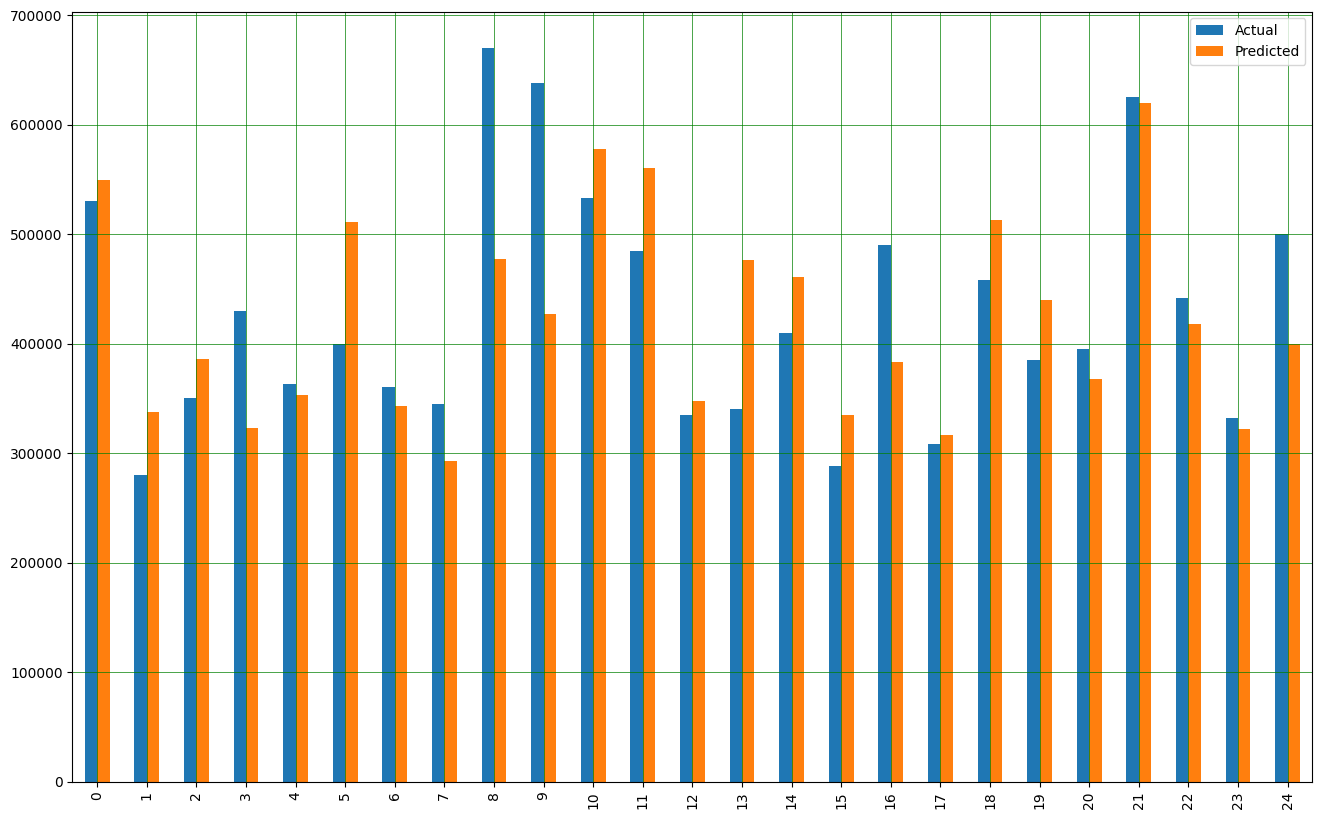

In [23]:
df1 = df.head(25)
df1.plot(kind='bar',figsize=(16,10))
plt.grid(which='major', linestyle='-', linewidth='0.5', color='green')
plt.grid(which='minor', linestyle=':', linewidth='0.5', color='black')
plt.show()

In [24]:
print('Mean Absolute Error:', metrics.mean_absolute_error(y_test, y_pred))
print('Mean Squared Error:', metrics.mean_squared_error(y_test, y_pred))
print('Root Mean Squared Error:', np.sqrt(metrics.mean_squared_error(y_test, y_pred)))

Mean Absolute Error: 72375.12812853018
Mean Squared Error: 10004223126.352516
Root Mean Squared Error: 100021.11340288367


In [25]:

aa= np.array([123,1989])
aa = np.reshape(aa,[1,2])
price = regressor.predict(aa)
print('\ninputs= ',aa,'\tprice= ',price)


inputs=  [[ 123 1989]] 	price=  [[536587.99167399]]
